In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cva import *

In [ ]:
L_over_V0 = 0.8
S0_over_K = 1.0
sigma_s = 0.25
sigma_v = 0.30
mu_v = 0.03
rho = 0.0

cva_control, se_control = black_cox_mc_control(
    L_over_V0=L_over_V0,
    S0_over_K=S0_over_K,
    sigma_s=sigma_s,
    sigma_v=sigma_v,
    mu_v=mu_v,
    rho=rho,
    n_paths=100_000,
    n_steps=200,
    seed=42
)

V0 = 100
S0 = 100
L = V0 * L_over_V0
K = S0 / S0_over_K

cva_analytic = cva_bc_ind(
    V0=V0,
    mu_v=mu_v,
    sigma_v=sigma_v,
    T=1,
    L=L,
    S0=S0,
    r_s=0.02,
    sigma_s=sigma_s,
    K=K,
    recovery_rate=0.4
)

print("Control CVA:", cva_control)
print("Analytical CVA:", cva_analytic)
print("Difference:", cva_control - cva_analytic)
print("Standard error:", se_control)

In [14]:
df_train = pd.read_csv('cva_training_dataset.csv')
df_validation = pd.read_csv('cva_validation_dataset.csv')

In [16]:
df_train.head()

,L_over_V0,S0,sigma_v,sigma_s,rho,CVA
0,0.05,80,0.1,0.10,-0.95,1.525124e-187
1,0.05,80,0.1,0.10,-0.50,3.360901e-188
2,0.05,80,0.1,0.10,0.00,1.960533e-191
3,0.05,80,0.1,0.10,0.50,1.923097e-271
4,0.05,80,0.1,0.35,-0.95,4.889506e-185


In [17]:
df_validation.head()

,L_over_V0,S0,sigma_v,sigma_s,rho,CVA
0,0.05,95,0.15,0.15,-0.75,7.320975e-83
1,0.05,95,0.15,0.15,-0.25,9.854989e-84
2,0.05,95,0.15,0.15,0.40,3.683677e-103
3,0.05,95,0.15,0.15,0.95,0.000000e+00
4,0.05,95,0.15,0.65,-0.75,1.146654e-79


In [18]:
df_train.describe()

,L_over_V0,S0,sigma_v,sigma_s,rho,CVA
count,324.000000,324.000000,324.000000,324.000000,324.000000,3.240000e+02
mean,0.250000,100.000000,0.466667,0.416667,-0.237500,1.301474e+00
std,0.187372,16.355191,0.330494,0.290084,0.543258,3.397355e+00
min,0.050000,80.000000,0.100000,0.100000,-0.950000,1.923097e-271
25%,0.050000,80.000000,0.100000,0.100000,-0.612500,7.838984e-16
50%,0.200000,100.000000,0.400000,0.350000,-0.250000,4.177786e-04
75%,0.500000,120.000000,0.900000,0.800000,0.125000,4.301579e-01
max,0.500000,120.000000,0.900000,0.800000,0.500000,2.726041e+01


In [19]:
df_validation.describe()

,L_over_V0,S0,sigma_v,sigma_s,rho,CVA
count,216.000000,216.000000,216.000000,216.000000,216.000000,2.160000e+02
mean,0.250000,105.000000,0.583333,0.583333,0.087500,1.873925e+00
std,0.200465,8.183932,0.330750,0.330750,0.645093,4.486544e+00
min,0.050000,95.000000,0.150000,0.150000,-0.750000,0.000000e+00
25%,0.050000,95.000000,0.150000,0.150000,-0.375000,6.159786e-25
50%,0.250000,105.000000,0.650000,0.650000,0.075000,6.579665e-04
75%,0.450000,115.000000,0.950000,0.950000,0.537500,9.307340e-01
max,0.450000,115.000000,0.950000,0.950000,0.950000,2.552633e+01


<Axes: >

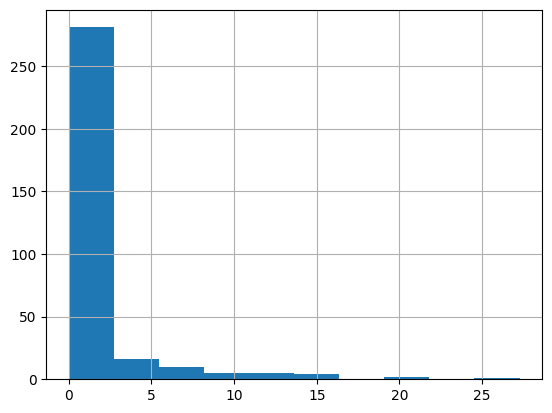

In [22]:
df_train['CVA'].hist(bins=10)

<Axes: >

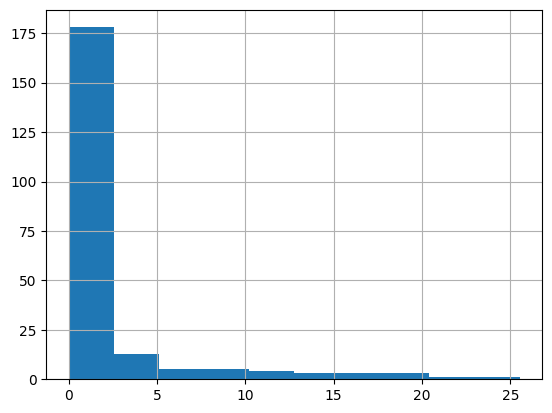

In [24]:
df_validation['CVA'].hist(bins=10)

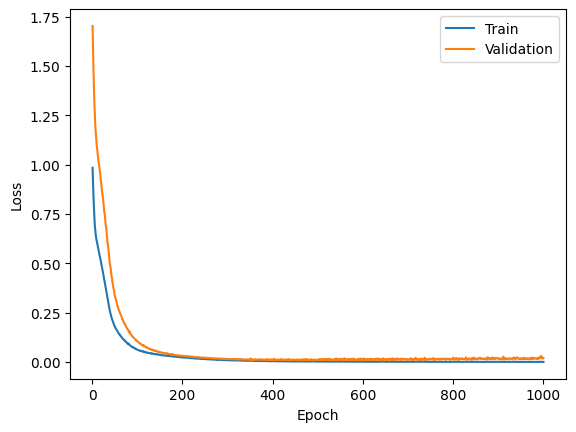

In [27]:
loss_df = pd.read_csv("nn_training.csv")

plt.plot(loss_df["epoch"], loss_df["train_loss"], label="Train")
plt.plot(loss_df["epoch"], loss_df["validation_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Root Mean Squared Error: 0.2540


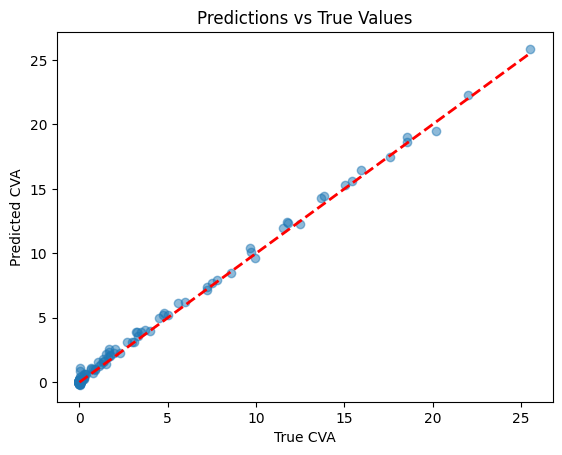

In [32]:
prediction_df = pd.read_csv("nn_predictions.csv")

plt.scatter(prediction_df["True_CVA"], prediction_df["Predicted_CVA"], alpha=0.5)
plt.plot([prediction_df["True_CVA"].min(), prediction_df["True_CVA"].max()], [prediction_df["True_CVA"].min(), prediction_df["True_CVA"].max()], 'r--', lw=2)
plt.xlabel("True CVA")
plt.ylabel("Predicted CVA")
plt.title("Predictions vs True Values")
plt.show()


In [35]:
RMSE = np.sqrt(np.mean((prediction_df["True_CVA"] - prediction_df["Predicted_CVA"]) ** 2))
print(f"Root Mean Squared Error: {RMSE:.4f}")

Root Mean Squared Error: 0.2540


In [39]:
results_df = df_validation.copy()
results_df["Predicted_CVA"] = prediction_df["Predicted_CVA"]
results_df["abs_error"] = np.abs(results_df["CVA"] - results_df["Predicted_CVA"])
print(f"Error by rho: {results_df.groupby('rho')['abs_error'].mean().to_string()}")
print(f"Error by L_over_V0: {results_df.groupby('L_over_V0')['abs_error'].mean().to_string()}")
print(f"Error by sigma_v: {results_df.groupby('sigma_v')['abs_error'].mean().to_string()}")

Error by rho: rho
-0.75    0.214369
-0.25    0.184293
 0.40    0.103038
 0.95    0.122339
Error by L_over_V0: L_over_V0
0.05    0.075899
0.45    0.236120
Error by sigma_v: sigma_v
0.15    0.050882
0.65    0.165945
0.95    0.251203
